## Machine learning

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [57]:
data = pd.read_csv('../data/loan_data.csv')
data.head(5)

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,12.0,Urban,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,Rural,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,Rural,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone


In [58]:
print(data.shape)
print(data.shape[0])  # number of rows
print(data.shape[1])  # number of columns

(50, 20)
50
20


In [59]:
print(data.isnull().sum())
print(data.isnull().sum().sum())
print((data.isnull().sum().sum()/(data.shape[0]*data.shape[1]))*100)

Loan_ID                 0
Customer_Age            7
Gender                  7
Marital_Status          7
Dependents              7
Education_Level         7
Employment_Type         7
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          7
dtype: int64
133
13.3


In [60]:
(data.isnull().sum()/data.shape[0])*100

Loan_ID                  0.0
Customer_Age            14.0
Gender                  14.0
Marital_Status          14.0
Dependents              14.0
Education_Level         14.0
Employment_Type         14.0
Annual_Income           14.0
Credit_Score            14.0
Loan_Amount             14.0
Loan_Term_Months        14.0
Property_Area           14.0
Existing_Loan           14.0
Loan_Approval_Status    14.0
Application_Date        14.0
Last_Payment_Date       14.0
Interest_Rate           14.0
Number_of_Payments      14.0
Account_Balance         14.0
Contact_Method          14.0
dtype: float64

In [61]:
print(data.notnull().sum())
print(data.notnull().sum().sum())
print((data.notnull().sum().sum()/(data.shape[0]*data.shape[1]))*100)

Loan_ID                 50
Customer_Age            43
Gender                  43
Marital_Status          43
Dependents              43
Education_Level         43
Employment_Type         43
Annual_Income           43
Credit_Score            43
Loan_Amount             43
Loan_Term_Months        43
Property_Area           43
Existing_Loan           43
Loan_Approval_Status    43
Application_Date        43
Last_Payment_Date       43
Interest_Rate           43
Number_of_Payments      43
Account_Balance         43
Contact_Method          43
dtype: int64
867
86.7


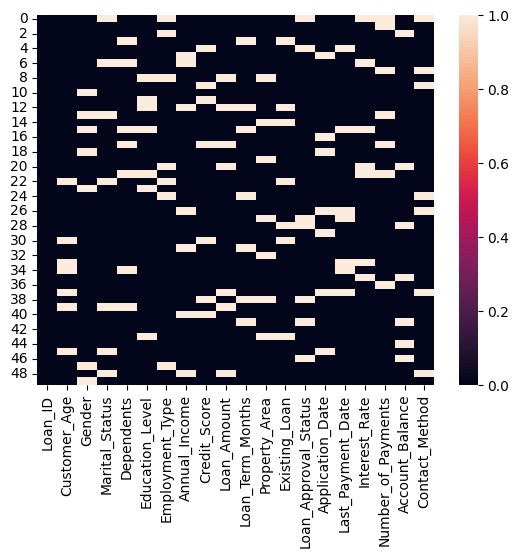

In [62]:
sns.heatmap(data.isnull())
plt.show()

## Deleting removing free and blank missing values from the dataset

In [63]:
data.head(4)

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,12.0,Urban,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,Rural,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch


In [64]:
data.shape

(50, 20)

In [65]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  7
Marital_Status          7
Dependents              7
Education_Level         7
Employment_Type         7
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          7
dtype: int64

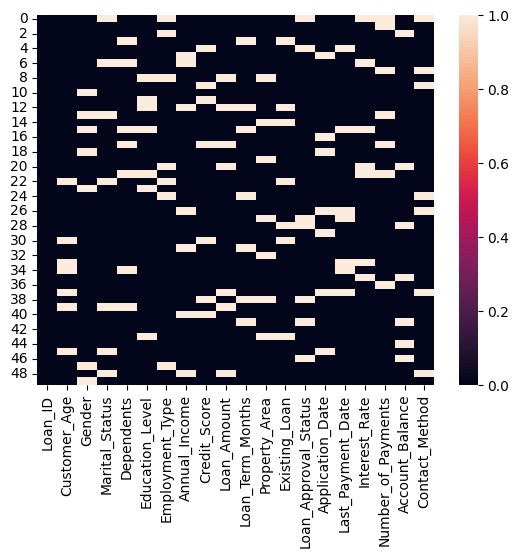

In [66]:
sns.heatmap(data.isnull())
plt.show()

In [67]:
# 1️⃣ Column names se extra spaces remove karo
data.columns = data.columns.str.strip()

# 2️⃣ Ab safe drop karo
# data.drop(columns=["Credit_Score"], inplace=True)

# 3️⃣ Check karlo
print(data.columns.tolist())



['Loan_ID', 'Customer_Age', 'Gender', 'Marital_Status', 'Dependents', 'Education_Level', 'Employment_Type', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Property_Area', 'Existing_Loan', 'Loan_Approval_Status', 'Application_Date', 'Last_Payment_Date', 'Interest_Rate', 'Number_of_Payments', 'Account_Balance', 'Contact_Method']


In [68]:
# data.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
print(data.isnull().sum())


Loan_ID                 0
Customer_Age            7
Gender                  7
Marital_Status          7
Dependents              7
Education_Level         7
Employment_Type         7
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          7
dtype: int64


In [69]:
data.shape


(50, 20)

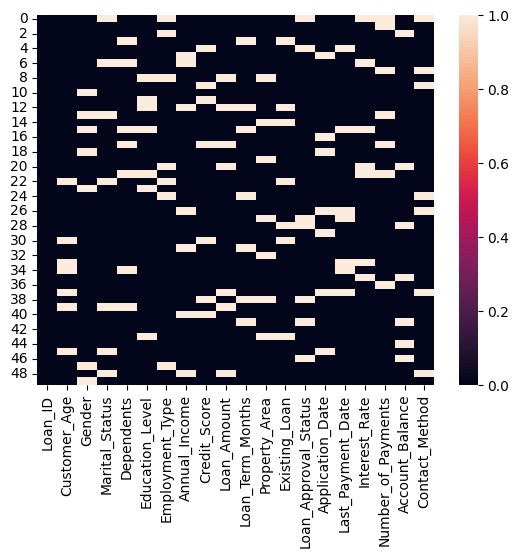

In [70]:
sns.heatmap(data.isnull())
plt.show()

In [71]:
# data.dropna(inplace=True)

In [72]:
data.shape

(50, 20)

In [73]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,12.0,Urban,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,Rural,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,Rural,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone


## Handaling missing values complete ho gaya. Ab aage badhte hain.

In [74]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  7
Marital_Status          7
Dependents              7
Education_Level         7
Employment_Type         7
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          7
dtype: int64

In [75]:
# data.fillna(10).head(10)


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          43 non-null     float64
 2   Gender                43 non-null     object 
 3   Marital_Status        43 non-null     object 
 4   Dependents            43 non-null     float64
 5   Education_Level       43 non-null     object 
 6   Employment_Type       43 non-null     object 
 7   Annual_Income         43 non-null     float64
 8   Credit_Score          43 non-null     float64
 9   Loan_Amount           43 non-null     float64
 10  Loan_Term_Months      43 non-null     float64
 11  Property_Area         43 non-null     object 
 12  Existing_Loan         43 non-null     object 
 13  Loan_Approval_Status  43 non-null     object 
 14  Application_Date      43 non-null     object 
 15  Last_Payment_Date     43 

In [77]:
data.fillna(method='bfill', axis=1)

C:\Users\HP\AppData\Local\Temp\ipykernel_20388\3719721641.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', axis=1)


,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,1.0,1.0,High School,146114.0,146114.0,815.0,18403.0,12.0,Urban,Yes,2025-11-24,2025-11-24,2025-10-02,1404.0,1404.0,1404.0,NaN
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,41943.0,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,70108.0,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,Branch,Branch
3,L1003,63.0,Female,Divorced,Graduate,Graduate,Salaried,132296.0,348.0,15966.0,Rural,Rural,Approved,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,38621.0,38621.0,60.0,Rural,No,2025-05-06,2025-05-06,10.53,10.53,39.0,13763.0,Phone
5,L1005,41.0,Female,Single,0.0,Postgraduate,Unemployed,316.0,316.0,33312.0,12.0,Urban,No,Rejected,2025-05-31,2025-05-31,7.51,39.0,19384.0,Phone
6,L1006,59.0,Male,Graduate,Graduate,Graduate,Self-employed,471.0,471.0,27677.0,60.0,Rural,Yes,Approved,2025-03-13,2025-11-18,48.0,48.0,33606.0,Phone
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,60.0,Urban,No,Approved,2025-02-22,2025-11-13,10.72,10860.0,10860.0,NaN
8,L1008,43.0,Female,Single,3.0,139181.0,139181.0,139181.0,457.0,60.0,60.0,Yes,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,47675.0,47675.0,36.0,Semiurban,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,NaN


In [78]:
data["Gender"].mode()[0]
data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_20388\2413550165.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)


In [79]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          43 non-null     float64
 2   Gender                50 non-null     object 
 3   Marital_Status        43 non-null     object 
 4   Dependents            43 non-null     float64
 5   Education_Level       43 non-null     object 
 6   Employment_Type       43 non-null     object 
 7   Annual_Income         43 non-null     float64
 8   Credit_Score          43 non-null     float64
 9   Loan_Amount           43 non-null     float64
 10  Loan_Term_Months      43 non-null     float64
 11  Property_Area         43 non-null     object 
 12  Existing_Loan         43 non-null     object 
 13  Loan_Approval_Status  43 non-null     object 
 14  Application_Date      43 non-null     object 
 15  Last_Payment_Date     43 

In [80]:
data.select_dtypes(include=['object']).isnull().sum()

Loan_ID                 0
Gender                  0
Marital_Status          7
Education_Level         7
Employment_Type         7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Contact_Method          7
dtype: int64

In [81]:
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          43 non-null     float64
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     object 
 4   Dependents            43 non-null     float64
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         43 non-null     float64
 8   Credit_Score          43 non-null     float64
 9   Loan_Amount           43 non-null     float64
 10  Loan_Term_Months      43 non-null     float64
 11  Property_Area         50 non-null     object 
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [83]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  0
Marital_Status          0
Dependents              7
Education_Level         0
Employment_Type         0
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          0
dtype: int64

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          43 non-null     float64
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     object 
 4   Dependents            43 non-null     float64
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         43 non-null     float64
 8   Credit_Score          43 non-null     float64
 9   Loan_Amount           43 non-null     float64
 10  Loan_Term_Months      43 non-null     float64
 11  Property_Area         50 non-null     object 
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [85]:
data.select_dtypes(include=['float64']).columns

Index(['Customer_Age', 'Dependents', 'Annual_Income', 'Credit_Score',
       'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate',
       'Number_of_Payments', 'Account_Balance'],
      dtype='object')

In [86]:
si = SimpleImputer(strategy="mean")
ar = si.fit_transform(data[['Customer_Age', 'Dependents', 'Annual_Income', 'Credit_Score',
       'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate',
       'Number_of_Payments', 'Account_Balance']])

In [87]:
new_data = pd.DataFrame(ar,columns=data.select_dtypes(include=['float64']).columns)

In [88]:
new_data.isnull().sum()

Customer_Age          0
Dependents            0
Annual_Income         0
Credit_Score          0
Loan_Amount           0
Loan_Term_Months      0
Interest_Rate         0
Number_of_Payments    0
Account_Balance       0
dtype: int64

In [89]:
new_data

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance
0,59.000000,1.000000,146114.000000,815.000000,18403.000000,12.000000,8.946977,36.302326,1404.000000
1,49.000000,1.000000,81135.000000,846.000000,37097.000000,24.000000,11.000000,36.302326,41943.000000
2,35.000000,3.000000,70108.000000,491.000000,18121.000000,12.000000,12.080000,37.000000,25792.511628
3,63.000000,2.162791,132296.000000,348.000000,15966.000000,37.395349,12.390000,19.000000,30189.000000
4,28.000000,2.000000,114179.000000,558.930233,38621.000000,60.000000,10.530000,39.000000,13763.000000
5,41.000000,0.000000,86066.744186,316.000000,33312.000000,12.000000,7.510000,39.000000,19384.000000
6,59.000000,2.162791,86066.744186,471.000000,27677.000000,60.000000,8.946977,48.000000,33606.000000
7,39.000000,4.000000,43328.000000,519.000000,36289.000000,60.000000,10.720000,36.302326,10860.000000
8,43.000000,3.000000,139181.000000,457.000000,26208.209302,60.000000,8.970000,47.000000,39757.000000
9,31.000000,4.000000,111412.000000,558.930233,47675.000000,36.000000,7.890000,38.000000,16106.000000


In [90]:
data["Loan_Amount"].mean()

np.float64(26208.20930232558)

In [91]:
new_data

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance
0,59.000000,1.000000,146114.000000,815.000000,18403.000000,12.000000,8.946977,36.302326,1404.000000
1,49.000000,1.000000,81135.000000,846.000000,37097.000000,24.000000,11.000000,36.302326,41943.000000
2,35.000000,3.000000,70108.000000,491.000000,18121.000000,12.000000,12.080000,37.000000,25792.511628
3,63.000000,2.162791,132296.000000,348.000000,15966.000000,37.395349,12.390000,19.000000,30189.000000
4,28.000000,2.000000,114179.000000,558.930233,38621.000000,60.000000,10.530000,39.000000,13763.000000
5,41.000000,0.000000,86066.744186,316.000000,33312.000000,12.000000,7.510000,39.000000,19384.000000
6,59.000000,2.162791,86066.744186,471.000000,27677.000000,60.000000,8.946977,48.000000,33606.000000
7,39.000000,4.000000,43328.000000,519.000000,36289.000000,60.000000,10.720000,36.302326,10860.000000
8,43.000000,3.000000,139181.000000,457.000000,26208.209302,60.000000,8.970000,47.000000,39757.000000
9,31.000000,4.000000,111412.000000,558.930233,47675.000000,36.000000,7.890000,38.000000,16106.000000


In [92]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,Divorced,1.0,High School,Self-employed,146114.0,815.0,18403.0,12.0,Urban,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,Self-employed,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,Rural,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,Rural,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone


In [93]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  0
Marital_Status          0
Dependents              7
Education_Level         0
Employment_Type         0
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          0
dtype: int64

In [94]:
data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)
data["Marital_Status"].fillna(data["Marital_Status"].mode()[0],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_20388\1278339984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_20388\1278339984.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [95]:
en_data = data[["Gender","Marital_Status"]]
en_data

,Gender,Marital_Status
0,Male,Divorced
1,Female,Single
2,Male,Single
3,Female,Divorced
4,Male,Single
5,Female,Single
6,Male,Divorced
7,Male,Divorced
8,Female,Single
9,Male,Single


In [96]:
pd.get_dummies(en_data)


,Gender_Female,Gender_Male,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single
0,False,True,True,False,False
1,True,False,False,False,True
2,False,True,False,False,True
3,True,False,True,False,False
4,False,True,False,False,True
5,True,False,False,False,True
6,False,True,True,False,False
7,False,True,True,False,False
8,True,False,False,False,True
9,False,True,False,False,True


In [97]:
ohe = OneHotEncoder(drop="first")
ar = ohe.fit_transform(en_data).toarray()
ar

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 1.],
       [0., 0., 0.],
       [1., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [1., 0., 1.],
       [0., 0., 1.],
       [1., 1., 0.],
       [0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.],
       [0., 0

In [98]:
pd.DataFrame(ar,columns=["Gender_Male","Marital_Status_Married","Marital_Status_Single"])

,Gender_Male,Marital_Status_Married,Marital_Status_Single
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,1.0
3,0.0,0.0,0.0
4,1.0,0.0,1.0
5,0.0,0.0,1.0
6,1.0,0.0,0.0
7,1.0,0.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,1.0


In [99]:
df = pd.DataFrame({"name":["wscube","cow","dog","cat","black","chair"]})
df

,name
0,wscube
1,cow
2,dog
3,cat
4,black
5,chair


In [100]:
le = LabelEncoder()
df["en_name"]= le.fit_transform(df[["name"]])

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [101]:
df

,name,en_name
0,wscube,5
1,cow,3
2,dog,4
3,cat,1
4,black,0
5,chair,2


In [102]:
data.head()
print(data["Property_Area"].unique())

['Urban' 'Rural' 'Semiurban']


In [103]:
la = LabelEncoder()
la.fit(data["Property_Area"])


LabelEncoder()

In [104]:
data["Property_Area"]=la.transform(data["Property_Area"])
data

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,Divorced,1.0,High School,Self-employed,146114.0,815.0,18403.0,12.0,2,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,2,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,Self-employed,70108.0,491.0,18121.0,12.0,2,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,0,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,0,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone
5,L1005,41.0,Female,Single,0.0,Postgraduate,Unemployed,NaN,316.0,33312.0,12.0,2,No,Rejected,2025-02-17,2025-05-31,7.51,39.0,19384.0,Phone
6,L1006,59.0,Male,Divorced,NaN,Graduate,Self-employed,NaN,471.0,27677.0,60.0,0,Yes,Approved,2025-03-13,2025-11-18,NaN,48.0,33606.0,Phone
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,60.0,2,No,Approved,2025-02-22,2025-11-13,10.72,NaN,10860.0,Branch
8,L1008,43.0,Female,Single,3.0,Postgraduate,Self-employed,139181.0,457.0,NaN,60.0,2,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,NaN,47675.0,36.0,1,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,Branch
